### 🛍️ **03. Clustering avec K-Means**

Bienvenue dans le monde de l'**Apprentissage Non Supervisé** ! Ici, nous n'avons pas de "réponse" (étiquette) à prédire. Le but est de découvrir des structures cachées dans les données.

---

#### **Objectif**
Segmenter les clients d'un centre commercial en groupes homogènes pour adapter les stratégies marketing.

#### 📌 **Plan du notebook**
- 📥 Chargement des librairies
- 📊 Présentation du dataset Mall Customers
- 📐 La méthode du coude (Elbow Method) pour choisir K
- 🤖 Entraînement de K-Means
- 🎨 Visualisation des clusters

### 📥 **Chargement des librairies**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

print("✅ Librairies prêtes !")

✅ Librairies prêtes !


### 📊 **Présentation du dataset**

🔗 Lien Kaggle : [Mall Customer Segmentation](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)

Nous allons utiliser deux variables :
- `Annual Income` : Revenu annuel
- `Spending Score` : Score de dépense (attribué par le centre commercial)

In [26]:
# Chargement manuel des données (simulation du dataset Kaggle)

url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

try:
    df = pd.read_csv(url)
    print("Données chargées avec succès !")
except Exception as e:
    print(f"Erreur lors du chargement : {e}")

df.head()

Données chargées avec succès !


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 📐 **Combien de clusters choisir ? (Elbow Method)**

L'**inertie** mesure la distance entre les points et le centre de leur cluster. On cherche le "coude" dans la courbe.

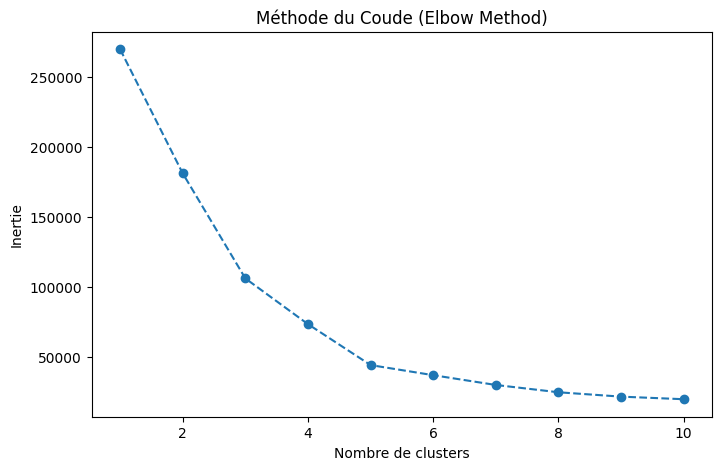

In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]  # DataFrame avec les deux caractéristiques pour le clustering

wcss = [] # Within-Cluster Sum of Square
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)  
    wcss.append(kmeans.inertia_)  

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Méthode du Coude (Elbow Method)')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.show()

### Explication :

🔎 1. Ce que représente ce graphe

- *Axe X* : nombre de clusters k
- *Axe Y* (inertie / WCSS) : somme des distances au carré entre chaque point et le centroïde de son cluster

- 👉 Formellement, l’inertie mesure la compacité des clusters :

- **Plus elle est faible, plus les clusters sont homogènes**
- **Elle diminue toujours quand k augmente** (car plus de clusters = meilleure adaptation)


⚙️ 2. Principe de la méthode du coude

On cherche le point où :

- Ajouter un cluster n’apporte plus beaucoup de gain
- La courbe passe d’une forte décroissance à une diminution plus lente

Ce point forme un “coude” (elbow).



📊 3. Interprétation du graphe

Dans ce cas :

    - Entre k = 1 → 3 : **forte baisse de l’inertie**
        ➜ gros gain en structuration des données

    - Entre k = 3 → 5 : **baisse encore significative mais moins brutale**

    - À partir de k ≥ 5 : **la courbe s’aplatit clairement**
        ➜ gains marginaux

👉 Conclusion : le “coude” est autour de k = 5


🎯 4. Choix du nombre de clusters

➡️ Le nombre optimal de clusters est k ≈ 5

**Pourquoi ?**

- Avant 5 : amélioration importante
- Après 5 : amélioration marginale → sur-segmentation possible


⚠️ 5. Points d’attention

- La méthode du coude est heuristique (pas une règle absolue)
- Parfois le coude n’est pas très net
- Tu peux confirmer avec d’autres métriques :
    - Silhouette Score
    - Davies-Bouldin Index

    

### 🤖 **Entraînement du modèle**

Le coude semble être à **5 clusters**. Entraînons notre modèle.

In [17]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

print("🚀 Clustering terminé !")
df.sample(5)  

🚀 Clustering terminé !


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
199,200,Male,30,137,83,1
65,66,Male,18,48,59,0
73,74,Female,60,50,56,0
86,87,Female,55,57,58,0
171,172,Male,28,87,75,1


### 🎨 **Visualisation des segments de clients**

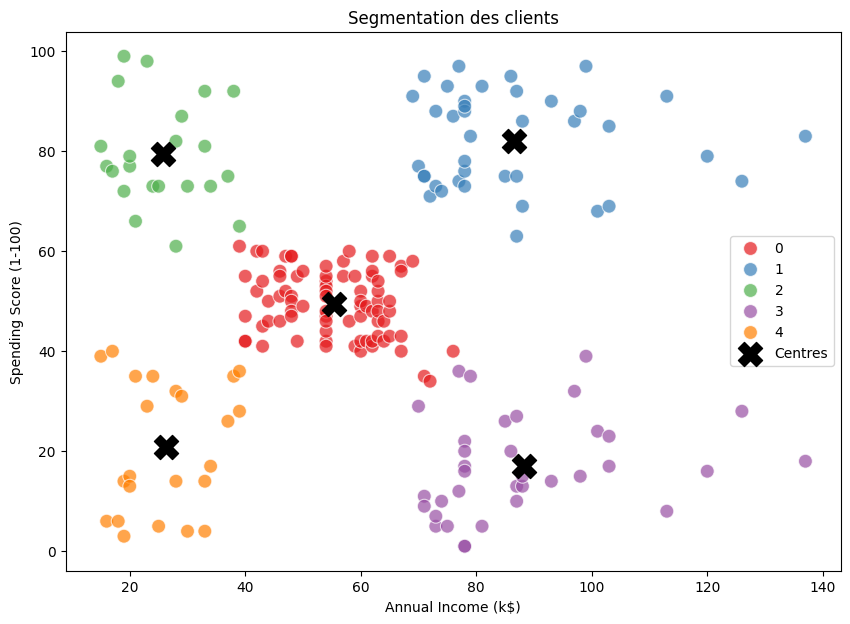

In [25]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster',   # Colorer par cluster
                palette='Set1',  # Palette de couleurs . Autres options : 'viridis', 'tab10', 'Set2', etc.
                s=100,   # Taille des points
                alpha=0.7)   # Transparence des points



# Ajouter les centres des clusters  
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],   # Coordonnées des centres : kmeans.cluster_centers_[:, 0] pour l'axe x, kmeans.cluster_centers_[:, 1] pour l'axe y
            s=300, 
            c='black', # Couleur noire pour les centres
            marker='X', 
            label='Centres')

plt.title("Segmentation des clients")
plt.legend()
plt.show()

### ✅ * Explication et *interprétation**


### 🔎 1. Ce que montre ce graphe

Chaque point = un client

**Axes** :
- X = revenu annuel (Annual Income)
- Y = score de dépense (Spending Score)

**Couleur** = cluster assigné par K-Means

**Croix noires (X)** = centroïdes (moyennes des clusters)

👉 Tu visualises donc la segmentation client en 5 groupes (k=5).



### 📊 2. Lecture cluster par cluster

- 🔴 Cluster rouge (centre ~ [55, 50])
    - Revenu moyen
    - Dépenses moyennes

👉 Clients standards / cœur de marché


- 🔵 Cluster bleu (centre ~ [85, 82])
    - Revenu élevé
    - Dépenses élevées
    
👉 Clients premium (cibles prioritaires)

💡 Haute valeur business


- 🟢 Cluster vert (centre ~ [25, 80])
    - Faible revenu
    - Dépenses élevées

👉 Clients impulsifs / sensibles au marketing

⚠️ Potentiel risque (faible capacité financière)


- 🟣 Cluster violet (centre ~ [90, 15])
    - Revenu élevé
    - Dépenses faibles

👉 Clients riches mais peu engagés

💡 Opportunité marketing (à activer)


- 🟠 Cluster orange (centre ~ [25, 20])
    - Faible revenu
    - Faibles dépenses
    
👉 Clients à faible valeur


### 🧠 3. Comment interpréter pour la décision

Ce graphe sert à faire de la segmentation stratégique.

🎯 Actions concrètes :

1. Cibler les clients à forte valeur
- 🔵 (haut revenu / forte dépense)

        ➡️ fidélisation, programmes VIP


2. Activer les clients sous-exploités
- 🟣 (haut revenu / faible dépense)

        ➡️ promotions ciblées, offres personnalisées


3. Contrôler les comportements à risque
- 🟢 (faible revenu / forte dépense)

        ➡️ marketing prudent (éviter sur-sollicitation)

4. Optimiser les coûts marketing
- 🟠 (faible revenu / faible dépense)

        ➡️ peu d’investissement marketing

5. Maintenir le cœur de marché
- 🔴 (moyen / moyen)

        ➡️ campagnes standard

### ⚙️ 4. Qualité du clustering

Notre clustering est bon pour plusieurs raisons :

- ✅ Clusters bien séparés visuellement
- ✅ Centroïdes bien positionnés
- ✅ Structure logique (interprétable métier)


⚠️ Limite :

- *K-Means* suppose des clusters “ronds”
- Sensible à l’échelle → normalisation parfois nécessaire



Le modèle K-Means avec k=5 permet d’identifier cinq segments de clients distincts basés sur leur revenu annuel et leur score de dépense. On observe des groupes homogènes et bien séparés, notamment un segment de clients à forte valeur (revenu élevé et dépenses élevées) ainsi qu’un segment de clients à fort potentiel (revenu élevé mais faible dépense). Cette segmentation permet de définir des stratégies marketing différenciées adaptées à chaque groupe.